In [16]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import CubicSpline

torch.set_default_dtype(torch.float64)

In [17]:
%run func_defs.ipynb

## 2D interpolator  (adapted from `interp_defs.ipynb`)

The axes are now `z` (space) and `t` (time)
Pass `method='linear'` or `method='cubic'` as the key arguments

In [18]:
def pt_2d_interpolation(z, t, U, **kwargs):
  
    interp_np = RegularGridInterpolator(
        (z.cpu().numpy(), t.cpu().numpy()),
        U.cpu().numpy(),
        **kwargs
    )

    def interp(z_q, t_q):
        z_q, t_q = torch.broadcast_tensors(
            torch.as_tensor(z_q, dtype=U.dtype),
            torch.as_tensor(t_q, dtype=U.dtype),
        )
        vals = interp_np((z_q.cpu().numpy(), t_q.cpu().numpy()))
        return torch.from_numpy(vals).to(device=U.device, dtype=U.dtype)

    return interp

## FD solver helper functions (unchanged from v7)

In [19]:
def set_BCs(T):
    T[0]  = T[2]
    T[-1] = T[-2] ** 2 / max(T[-3].item(), 1e-40)

In [20]:
def solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, n_t_out, device, verbose=True):
    """
    Solve the two-layer heat equation from t=0 to t=tf.
    Returns (z, t_out, U_coarse): shapes (nz+1,), (n_t_out,), (nz+1, n_t_out).
    """
    dz = Lz / nz
    z  = torch.arange(-1, nz + 2, device=device) * dz

    m = torch.searchsorted(z, z_dis - 0.5 * dz, right=True).item()
    if verbose:
        print(f'Interface alignment error: {z[m].item() - z_dis:.2e}')

    k_iL = 8 * k1 * k2 / (k1 + 7 * k2)
    k_iR = 8 * k1 * k2 / (7 * k1 + k2)
    kh   = torch.where(
        z[:-1] < z_dis - 0.5 * dz,
        torch.tensor(k1, device=device),
        torch.tensor(k2, device=device),
    )
    kh[m - 1] = k_iL
    kh[m]     = k_iR

    dt_stab = 0.5 * (dz ** 2) / max(k1, k2)
    n_fine  = int(np.ceil(tf / dt_stab))
    dt      = tf / n_fine
    if verbose:
        print(f'n_fine={n_fine}, dt={dt:.4e}, tf={tf}')

    source    = Pda * torch.exp(-z[1:-1])
    source[0] = Pda * torch.exp(-z[2] / 4)

    T  = torch.zeros(nz + 3, device=device)

    stride        = max(1, n_fine // (10 * n_t_out))
    buf_steps     = list(range(stride - 1, n_fine, stride))
    if (n_fine - 1) not in buf_steps:
        buf_steps.append(n_fine - 1)
    buf_steps_set = set(buf_steps)

    buf_U, buf_t = [], []

    for step in range(n_fine):
        set_BCs(T)
        Jh      = -kh * (T[1:] - T[:-1]) / dz
        T[1:-1] = T[1:-1] + dt / dz * (Jh[:-1] - Jh[1:]) + dt * source
        if step in buf_steps_set:
            buf_U.append(T[1:-1].cpu().clone())
            buf_t.append((step + 1) * dt)

    set_BCs(T)
    T[m] = T[m] + (2 * T[m] - T[m - 1] - T[m + 1]) / 6

    t_fine_buf = np.array(buf_t)
    U_fine_buf = torch.stack(buf_U, dim=1).numpy()

    t_coarse = np.linspace(tf / n_t_out, tf, n_t_out)
    cs       = CubicSpline(t_fine_buf, U_fine_buf, axis=1, bc_type='not-a-knot')
    U_coarse = torch.from_numpy(cs(t_coarse)).to(device)

    return z[1:-1], torch.tensor(t_coarse, device=device), U_coarse

In [21]:
def smooth_U(U, z, z_dis, k1, k2):
    """Rescale the z < z_dis half to enforce the flux interface condition."""
    alpha    = k1 / k2
    m        = torch.searchsorted(z, torch.tensor(z_dis, device=z.device)).item()
    U_smooth = U.clone()
    U_smooth[:m, :] = U[m, :] + alpha * (U[:m, :] - U[m, :])
    return U_smooth

In [22]:
_VALID_KEYS = frozenset({
    'U', 'U_raw', 'z', 't', 'stau', 'W', 'kratio', 'z_dis',
    'dataset', 'interp', 'interp_lin',
})


class Solver:

    def __init__(self, k1, k2, z_dis, Pda, Lz, nz, tf, n_t_out,
                 device='cpu', verbose=True):
        self._p       = dict(k1=k1, k2=k2, z_dis=z_dis, Pda=Pda,
                             Lz=Lz, nz=nz, tf=tf, n_t_out=n_t_out,
                             device=device)
        self._verbose = verbose
        self._cache   = {}
        self._run()

    # ------------------------------------------------------------------
    def _run(self):
        p = self._p

        # 1. solve PDE
        z, t_out, U_raw = solve_two_layer_FD(
            p['k1'], p['k2'], p['z_dis'], p['Pda'],
            p['Lz'], p['nz'], p['tf'], p['n_t_out'],
            p['device'], verbose=self._verbose,
        )

        # 2. smooth across interface
        U_smooth = smooth_U(U_raw, z, p['z_dis'], p['k1'], p['k2'])

        # 3. 2D cubic and linear interpolants over (z, t) on the smoothed field
        interp_cub = pt_2d_interpolation(z, t_out, U_smooth,
                                         method='cubic',
                                         bounds_error=False,
                                         fill_value=None)
        interp_lin = pt_2d_interpolation(z, t_out, U_smooth,
                                         method='linear',
                                         bounds_error=False,
                                         fill_value=None)

        # 4. (s, tau) coordinates — from func_defs.ipynb
        zt_grid      = torch.cartesian_prod(z, t_out)
        zz, tt       = zt_grid[:, 0], zt_grid[:, 1]
        ss, ttau     = z_t_to_s_tau(zz, tt)
        stau         = torch.column_stack((ss, ttau))

        # 5. scaled solution W = U_smooth / t
        W = (U_smooth / t_out).reshape(-1, 1)

        # 6. per-point parameter tensors
        n_pts  = len(stau)
        kratio = torch.full((n_pts,), p['k1'] / p['k2'], device=p['device'])
        z_disv = torch.full((n_pts,), p['z_dis'],        device=p['device'])

        self._cache = {
            'U':          U_smooth,
            'U_raw':      U_raw,
            'z':          z,
            't':          t_out,
            'stau':       stau,
            'W':          W,
            'kratio':     kratio,
            'z_dis':      z_disv,
            'interp':     interp_cub,
            'interp_lin': interp_lin,
        }

    # ------------------------------------------------------------------
    def __getitem__(self, key):
        if key not in _VALID_KEYS:
            raise KeyError(f'Unknown key {key!r}. Valid keys: {sorted(_VALID_KEYS)}')
        if key == 'dataset':
            return self._build_dataset()
        return self._cache[key]

    def _build_dataset(self):
        c = self._cache
        return {
            't':      c['stau'][:, 1],
            'z':      c['stau'][:, 0],
            'kratio': c['kratio'],
            'zdis':   c['z_dis'],
            'stau':   c['stau'],
            'W':      c['W'],
        }

    def keys(self):
        return sorted(_VALID_KEYS)

    def save(self, path):
        """torch.save the dataset dict to path."""
        torch.save(self._build_dataset(), path)
        if self._verbose:
            print(f'Dataset saved to {path}')

    def __repr__(self):
        p = self._p
        return (f"Solver(k1={p['k1']}, k2={p['k2']}, z_dis={p['z_dis']}, "
                f"Pda={p['Pda']}, Lz={p['Lz']}, nz={p['nz']}, "
                f"tf={p['tf']}, n_t_out={p['n_t_out']}, device={p['device']!r})")

## Run the solver and inspect the interpolants

In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

sol = Solver(
    k1=1.0, k2=2.0, z_dis=1.0, Pda=1.0,
    Lz=16.0, nz=160, tf=2.0, n_t_out=80,
    device=device,
)
print(sol)
print('Keys:', sol.keys())

Interface alignment error: 0.00e+00
n_fine=800, dt=2.5000e-03, tf=2.0
Solver(k1=1.0, k2=2.0, z_dis=1.0, Pda=1.0, Lz=16.0, nz=160, tf=2.0, n_t_out=80, device='cuda')
Keys: ['U', 'U_raw', 'W', 'dataset', 'interp', 'interp_lin', 'kratio', 'stau', 't', 'z', 'z_dis']


In [24]:
interp     = sol['interp']      # cubic
interp_lin = sol['interp_lin']  # linear
z_grid     = sol['z']
t_grid     = sol['t']

# evaluate both at the original grid points — should match U closely
z2d, t2d = torch.meshgrid(z_grid, t_grid, indexing='ij')
U_cub_grid = interp(z2d, t2d)        # (nz+1, n_t_out)
U_lin_grid = interp_lin(z2d, t2d)

print(f'Max diff cubic  vs U on grid: {(U_cub_grid - sol["U"]).abs().max():.3e}')
print(f'Max diff linear vs U on grid: {(U_lin_grid - sol["U"]).abs().max():.3e}')

Max diff cubic  vs U on grid: 1.575e-05
Max diff linear vs U on grid: 0.000e+00


## Error comparison: coarse FD + interpolation  vs  fine FD reference

Strategy:
1. Solve at **coarse** `nz_c` and **fine** `nz_f` (reference).
2. Evaluate the coarse cubic and linear interpolants at the fine `z` grid.
3. Compare both to the fine reference solution.
4. Zoom in near `z_dis` to see which interpolant wins at the transition.

In [25]:
k1, k2, z_dis = 1.0, 2.0, 1.0
Pda, Lz, tf   = 1.0, 16.0, 2.0
n_t_out       = 80

nz_c = 80     # coarse
nz_f = 640    # fine reference  (8× finer)

print('Running coarse solver...')
sol_c = Solver(k1=k1, k2=k2, z_dis=z_dis, Pda=Pda,
               Lz=Lz, nz=nz_c, tf=tf, n_t_out=n_t_out,
               device=device, verbose=False)

print('Running fine solver (reference)...')
sol_f = Solver(k1=k1, k2=k2, z_dis=z_dis, Pda=Pda,
               Lz=Lz, nz=nz_f, tf=tf, n_t_out=n_t_out,
               device=device, verbose=False)
print('Done.')

Running coarse solver...
Running fine solver (reference)...
Done.


In [26]:
z_f   = sol_f['z']          # fine z grid  (nz_f+1,)
t_out = sol_f['t']          # shared time grid
U_ref = sol_f['U']          # fine reference  (nz_f+1, n_t_out)

# broadcast fine z and shared t into a 2D query
z_f2d, t_f2d = torch.meshgrid(z_f, t_out, indexing='ij')

# evaluate coarse interpolants at the fine grid
U_cub = sol_c['interp'    ](z_f2d, t_f2d)   # cubic
U_lin = sol_c['interp_lin'](z_f2d, t_f2d)   # linear

err_cub = (U_cub - U_ref).abs()
err_lin = (U_lin - U_ref).abs()

print(f'Cubic  — max: {err_cub.max():.3e},  mean: {err_cub.mean():.3e}')
print(f'Linear — max: {err_lin.max():.3e},  mean: {err_lin.mean():.3e}')

Cubic  — max: 3.731e-03,  mean: 2.073e-04
Linear — max: 3.355e-03,  mean: 1.490e-04


## Plots

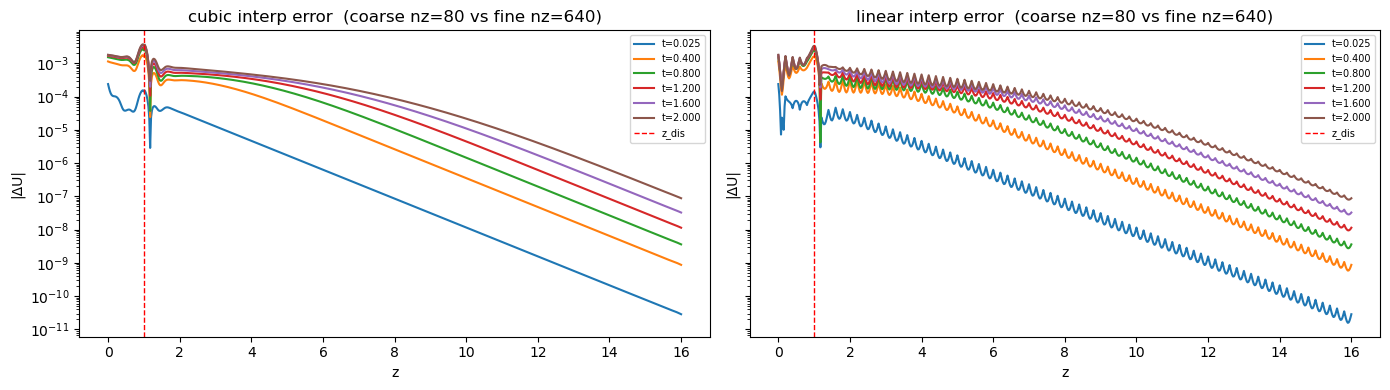

In [27]:
idx   = torch.linspace(0, n_t_out - 1, 6).long()
z_cpu = z_f.cpu();  t_cpu = t_out.cpu()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for err_cpu, label, ax in [
        (err_cub.cpu(), 'cubic',  axes[0]),
        (err_lin.cpu(), 'linear', axes[1]),
]:
    for i in idx:
        ax.semilogy(z_cpu, err_cpu[:, i].clamp(min=1e-16),
                    label=f't={t_cpu[i]:.3f}')
    ax.axvline(z_dis, color='r', linestyle='--', lw=1.0, label='z_dis')
    ax.set_xlabel('z'); ax.set_ylabel('|ΔU|')
    ax.set_title(f'{label} interp error  (coarse nz={nz_c} vs fine nz={nz_f})')
    ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

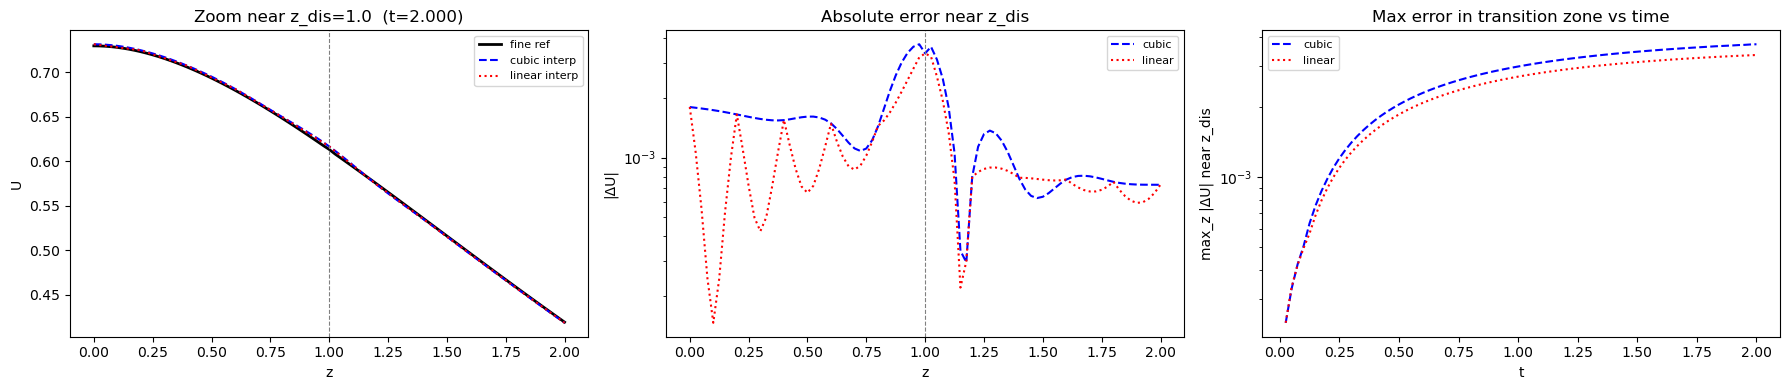

In [28]:
# zoom window around z_dis
dz_f   = (Lz / nz_f)
w      = max(1, nz_f // 16)          # points on each side
m_f = torch.searchsorted(z_f, torch.tensor(z_dis, device=z_f.device)).item()
sl     = slice(max(0, m_f - w), min(len(z_f), m_f + w + 1))
z_zoom = z_f[sl].cpu()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# panel 0: solutions at last time step
i_last = n_t_out - 1
ax = axes[0]
ax.plot(z_zoom, U_ref[sl, i_last].cpu(), 'k-',  lw=2,  label='fine ref')
ax.plot(z_zoom, U_cub[sl, i_last].cpu(), 'b--', lw=1.5, label='cubic interp')
ax.plot(z_zoom, U_lin[sl, i_last].cpu(), 'r:',  lw=1.5, label='linear interp')
ax.axvline(z_dis, color='gray', linestyle='--', lw=0.8)
ax.set_xlabel('z'); ax.set_ylabel('U')
ax.set_title(f'Zoom near z_dis={z_dis}  (t={t_cpu[i_last]:.3f})')
ax.legend(fontsize=8)

# panel 1: absolute error near z_dis
ax = axes[1]
ax.semilogy(z_zoom, err_cub[sl, i_last].cpu().clamp(min=1e-16), 'b--', label='cubic')
ax.semilogy(z_zoom, err_lin[sl, i_last].cpu().clamp(min=1e-16), 'r:',  label='linear')
ax.axvline(z_dis, color='gray', linestyle='--', lw=0.8)
ax.set_xlabel('z'); ax.set_ylabel('|ΔU|')
ax.set_title('Absolute error near z_dis')
ax.legend(fontsize=8)

# panel 2: max error over z near z_dis vs time
ax = axes[2]
ax.semilogy(t_cpu, err_cub[sl, :].max(dim=0).values.cpu(), 'b--', label='cubic')
ax.semilogy(t_cpu, err_lin[sl, :].max(dim=0).values.cpu(), 'r:',  label='linear')
ax.set_xlabel('t'); ax.set_ylabel('max_z |ΔU| near z_dis')
ax.set_title('Max error in transition zone vs time')
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

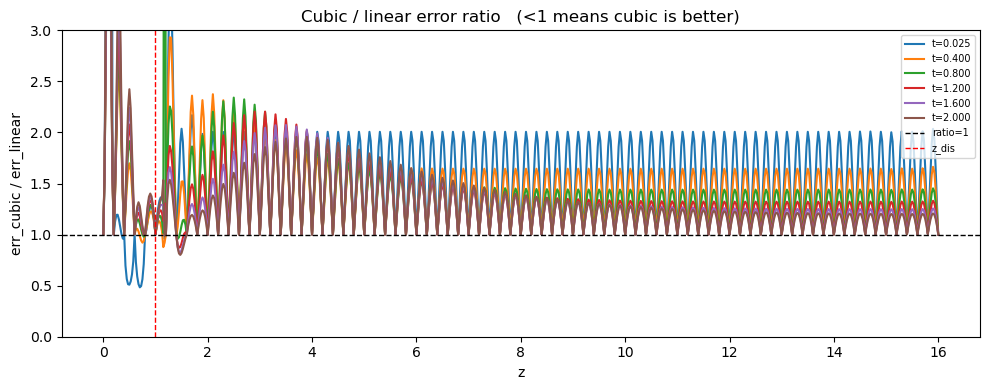

In [29]:
# ratio cubic/linear — values < 1 mean cubic wins
ratio = (err_cub / (err_lin + 1e-40)).cpu()

fig, ax = plt.subplots(figsize=(10, 4))
for i in idx:
    ax.plot(z_cpu, ratio[:, i], label=f't={t_cpu[i]:.3f}')
ax.axhline(1.0, color='k', linestyle='--', lw=1.0, label='ratio=1')
ax.axvline(z_dis, color='r', linestyle='--', lw=1.0, label='z_dis')
ax.set_xlabel('z'); ax.set_ylabel('err_cubic / err_linear')
ax.set_title('Cubic / linear error ratio   (<1 means cubic is better)')
ax.set_ylim(0, 3)
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Save dataset

In [ ]:
p        = sol._p
out_file = f'./data/2layer_k1{p["k1"]}_k2{p["k2"]}_nz{p["nz"]}.pt'
sol.save(out_file)